# 05. GARCH Model (Generalised Autoregressive Conditional Heteroscedasticity)

**Goal:** Model the **changing variance (volatility)** of NO2. Previous models captured the mean but assumed constant variance. The residual diagnostics showed this is wrong.

### Why GARCH?
From Notebooks 02-04:
- Residuals had **heavy tails** (Jarque-Bera p=0.00 and kurtosis ~3.7)
- **Heteroscedasticity** confirmed (Prob(H) = 0.00)
- Rolling variance showed **volatility clustering** where high variance periods are followed by high variance

### Theory

**ARCH(q):** Variance depends on past squared errors
$$\sigma_t^2 = \omega + \alpha_1 \varepsilon_{t-1}^2 + \cdots + \alpha_q \varepsilon_{t-q}^2$$

**GARCH(p,q):** Adds past variance terms (like ARMA for variance)
$$\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2$$

- $\alpha$ = how much past shocks affect current volatility
- $\beta$ = how persistent volatility is
- $\alpha + \beta < 1$ = volatility is mean-reverting

In [1]:
import sqlite3
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import jarque_bera
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

SAVED_DIR = "saved"
os.makedirs(SAVED_DIR, exist_ok=True)

print("All imports loaded ✓")

All imports loaded ✓


## 1. Load Data & Examine Volatility

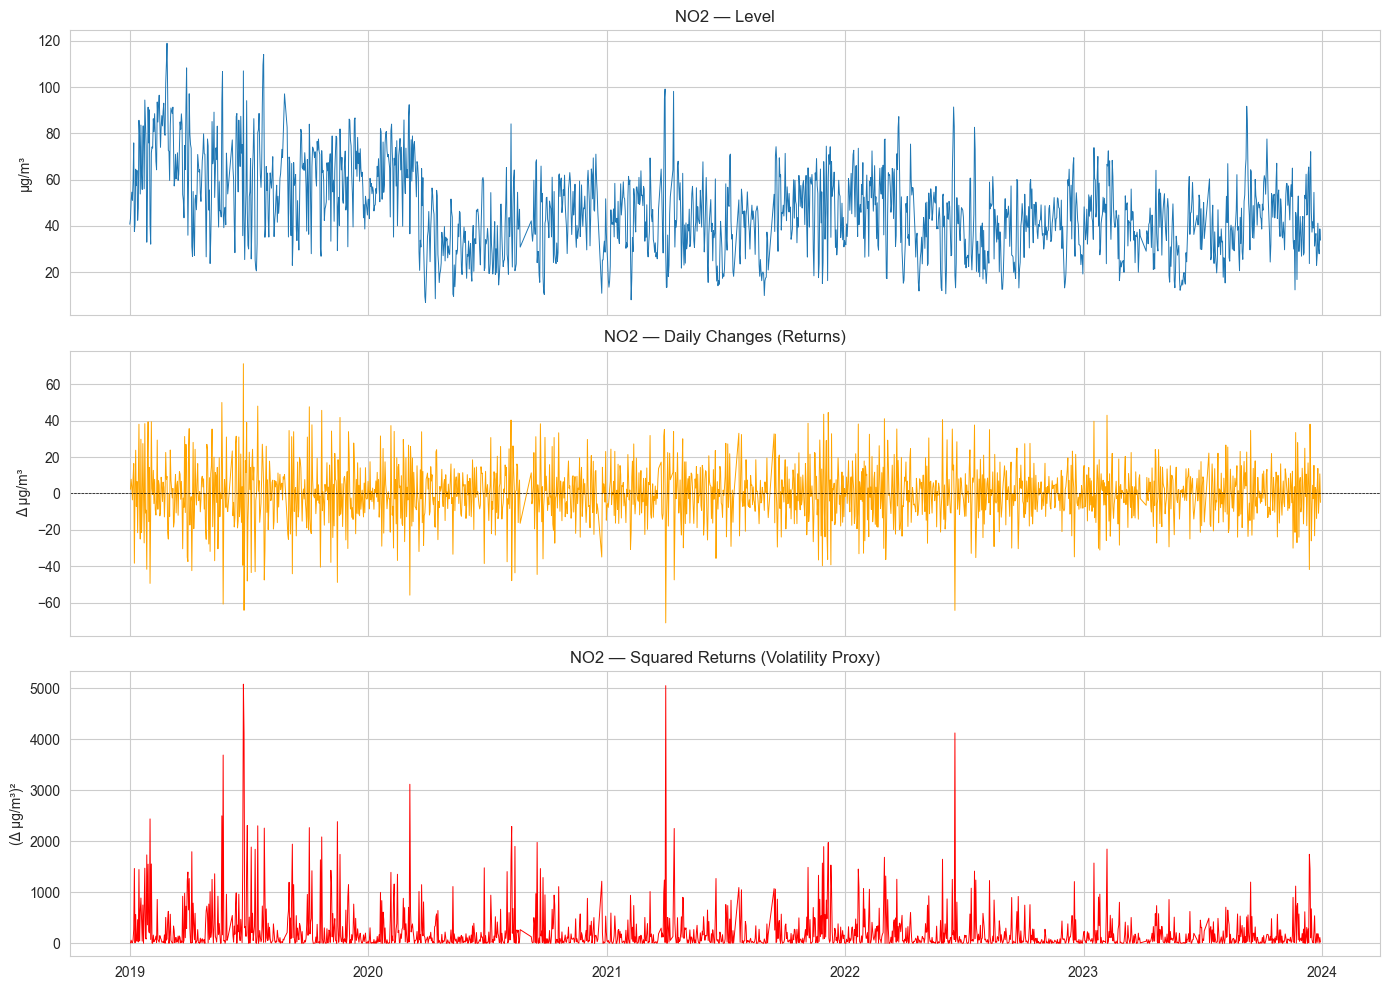

If squared returns cluster (high follows high), GARCH is appropriate.


In [2]:
DB_PATH = "../database/air_quality.db"
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM clean_daily_my1", conn, parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)
conn.close()

no2 = df["no2"].copy()
TEST_SIZE = 90
train = no2[:-TEST_SIZE]
test = no2[-TEST_SIZE:]

# Show volatility clustering: squared returns (daily changes)
returns = no2.diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(no2, linewidth=0.7)
axes[0].set_title("NO2 — Level")
axes[0].set_ylabel("µg/m³")

axes[1].plot(returns, linewidth=0.7, color="orange")
axes[1].set_title("NO2 — Daily Changes (Returns)")
axes[1].set_ylabel("Δ µg/m³")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")

axes[2].plot(returns**2, linewidth=0.7, color="red")
axes[2].set_title("NO2 — Squared Returns (Volatility Proxy)")
axes[2].set_ylabel("(Δ µg/m³)²")

plt.tight_layout()
plt.show()

print("If squared returns cluster (high follows high), GARCH is appropriate.")

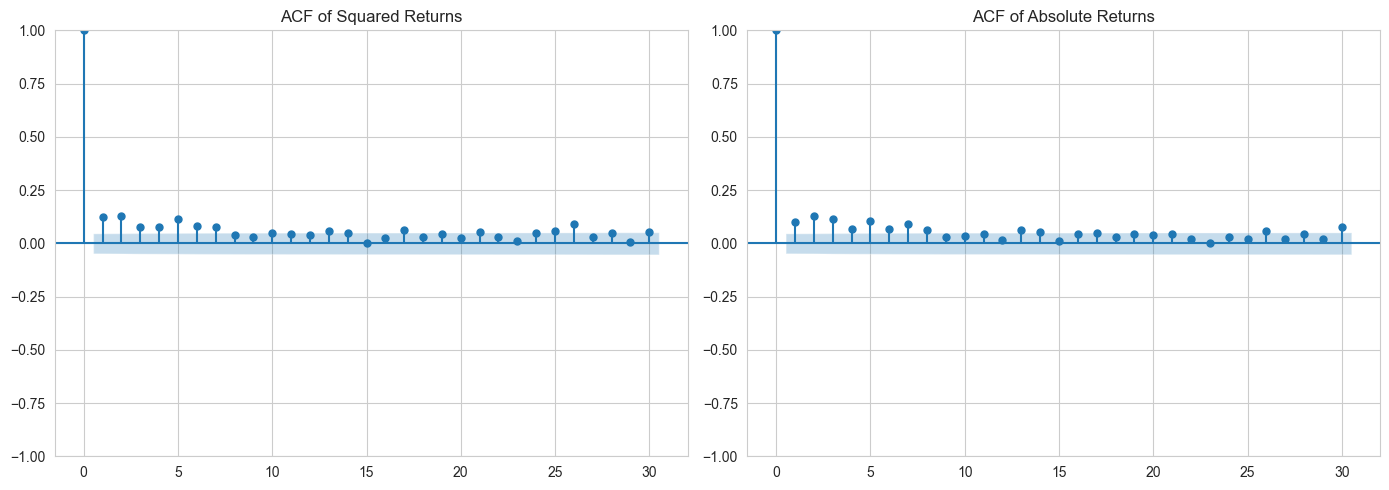

ARCH LM Test: stat=78.50, p=0.000000
✓ Significant ARCH effects — GARCH modelling is justified


In [3]:
# ACF of squared returns — tests for ARCH effects
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(returns**2, lags=30, ax=axes[0], title="ACF of Squared Returns")
plot_acf(returns.abs(), lags=30, ax=axes[1], title="ACF of Absolute Returns")

plt.tight_layout()
plt.show()

# ARCH LM test — formal test for ARCH effects
arch_stat, arch_p, _, _ = het_arch(returns, nlags=10)
print(f"ARCH LM Test: stat={arch_stat:.2f}, p={arch_p:.6f}")
if arch_p < 0.05:
    print("✓ Significant ARCH effects — GARCH modelling is justified")
else:
    print("✗ No significant ARCH effects")

## 2. ARIMA-GARCH: Two-Step Approach

**Step 1:** Fit ARIMA to model the **mean** (as before)
**Step 2:** Fit GARCH on ARIMA **residuals** to model the **variance**

This is how GARCH is typically used. It models the volatility of what ARIMA cannot explain.

✓ Loaded ARIMA model from saved/arima_best_fit.pkl
ARIMA residuals: 1662 values
Mean: -0.0223, Std: 13.45


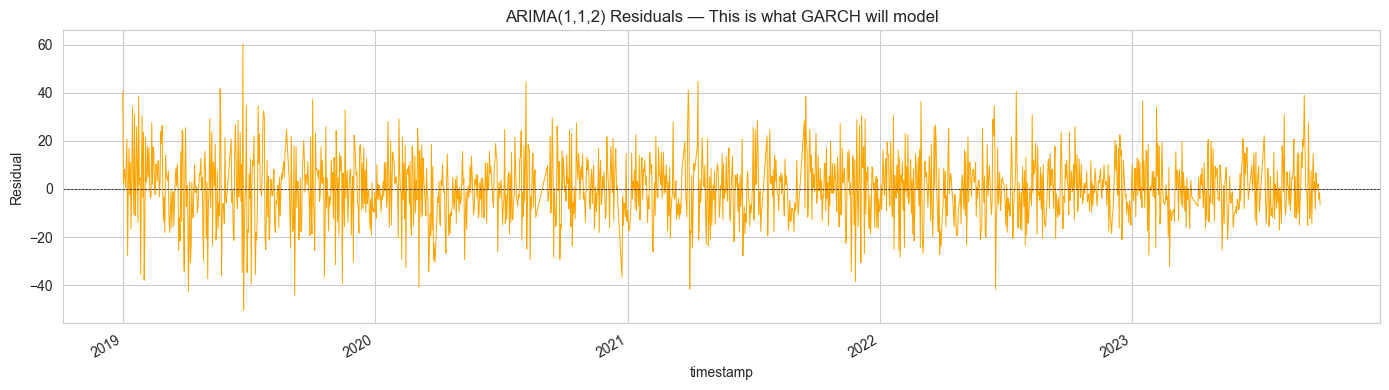

In [4]:
# Step 1: Fit ARIMA(1,1,2) on training data (reuse from Notebook 02)
ARIMA_PATH = os.path.join(SAVED_DIR, "arima_best_fit.pkl")

if os.path.exists(ARIMA_PATH):
    arima_fit = pickle.load(open(ARIMA_PATH, "rb"))
    print(f"✓ Loaded ARIMA model from {ARIMA_PATH}")
else:
    arima_model = ARIMA(train, order=(1, 1, 2))
    arima_fit = arima_model.fit()
    pickle.dump(arima_fit, open(ARIMA_PATH, "wb"))
    print("✓ Trained ARIMA(1,1,2)")

# Get ARIMA residuals
arima_resid = arima_fit.resid
print(f"ARIMA residuals: {len(arima_resid)} values")
print(f"Mean: {arima_resid.mean():.4f}, Std: {arima_resid.std():.2f}")

fig, ax = plt.subplots(figsize=(14, 4))
arima_resid.plot(ax=ax, linewidth=0.7, color="orange")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("ARIMA(1,1,2) Residuals — This is what GARCH will model")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()

## 3. Fit GARCH Models on ARIMA Residuals

In [5]:
# Grid search GARCH(p,q) on ARIMA residuals
GARCH_GRID_PATH = os.path.join(SAVED_DIR, "garch_grid_results.pkl")

if os.path.exists(GARCH_GRID_PATH):
    garch_results = pd.read_pickle(GARCH_GRID_PATH)
    print(f"✓ Loaded cached GARCH grid results from {GARCH_GRID_PATH}")
else:
    resid_train = arima_resid.dropna().values * 100  # scale up for numerical stability

    results = []
    for p in range(1, 4):
        for q in range(1, 4):
            try:
                model = arch_model(resid_train, vol="Garch", p=p, q=q, dist="t")
                fitted = model.fit(disp="off")
                results.append({
                    "order": f"GARCH({p},{q})",
                    "p": p, "q": q,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic,
                    "LogLik": fitted.loglikelihood,
                })
                print(f"  GARCH({p},{q}) | AIC: {fitted.aic:.1f} | BIC: {fitted.bic:.1f}")
            except Exception as e:
                print(f"  GARCH({p},{q}) | FAILED: {str(e)[:50]}")

    garch_results = pd.DataFrame(results).sort_values("AIC")
    garch_results.to_pickle(GARCH_GRID_PATH)
    print(f"\n✓ Saved GARCH grid results to {GARCH_GRID_PATH}")

print(f"\nTop GARCH models by AIC:")
display(garch_results[["order", "AIC", "BIC"]].reset_index(drop=True))

  GARCH(1,1) | AIC: 28572.6 | BIC: 28599.7
  GARCH(1,2) | AIC: 28573.3 | BIC: 28605.8
  GARCH(1,3) | AIC: 28575.1 | BIC: 28613.1
  GARCH(2,1) | AIC: 28574.6 | BIC: 28607.1
  GARCH(2,2) | AIC: 28575.3 | BIC: 28613.2
  GARCH(2,3) | AIC: 28577.1 | BIC: 28620.5
  GARCH(3,1) | AIC: 28576.6 | BIC: 28614.5
  GARCH(3,2) | AIC: 28577.3 | BIC: 28620.6
  GARCH(3,3) | AIC: 28579.1 | BIC: 28627.9

✓ Saved GARCH grid results to saved/garch_grid_results.pkl

Top GARCH models by AIC:


,order,AIC,BIC
0,"GARCH(1,1)",28572.616296,28599.695181
1,"GARCH(1,2)",28573.315764,28605.810426
2,"GARCH(2,1)",28574.616293,28607.110955
3,"GARCH(1,3)",28575.143116,28613.053555
4,"GARCH(2,2)",28575.315765,28613.226203
5,"GARCH(3,1)",28576.616294,28614.526733
6,"GARCH(2,3)",28577.140909,28620.467125
7,"GARCH(3,2)",28577.315764,28620.641979
8,"GARCH(3,3)",28579.140904,28627.882897


## 4. Best GARCH — Detailed Analysis

In [6]:
# Fit best GARCH model (or load from cache)
GARCH_PATH = os.path.join(SAVED_DIR, "garch_best_fit.pkl")

best_g = garch_results.iloc[0]
best_p, best_q = int(best_g["p"]), int(best_g["q"])
resid_scaled = arima_resid.dropna().values * 100

print(f"Best GARCH order: ({best_p},{best_q})\n")

if os.path.exists(GARCH_PATH):
    garch_fit = pickle.load(open(GARCH_PATH, "rb"))
    print(f"✓ Loaded cached GARCH model from {GARCH_PATH}")
else:
    garch_model = arch_model(resid_scaled, vol="Garch", p=best_p, q=best_q, dist="t")
    garch_fit = garch_model.fit(disp="off")
    pickle.dump(garch_fit, open(GARCH_PATH, "wb"))
    print(f"✓ Trained and saved GARCH({best_p},{best_q}) to {GARCH_PATH}")

print(garch_fit.summary())

Best GARCH order: (1,1)

✓ Trained and saved GARCH(1,1) to saved/garch_best_fit.pkl
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -14281.3
Distribution:      Standardized Student's t   AIC:                           28572.6
Method:                  Maximum Likelihood   BIC:                           28599.7
                                              No. Observations:                 1662
Date:                      Sat, Apr 04 2026   Df Residuals:                     1661
Time:                              12:07:28   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
-----

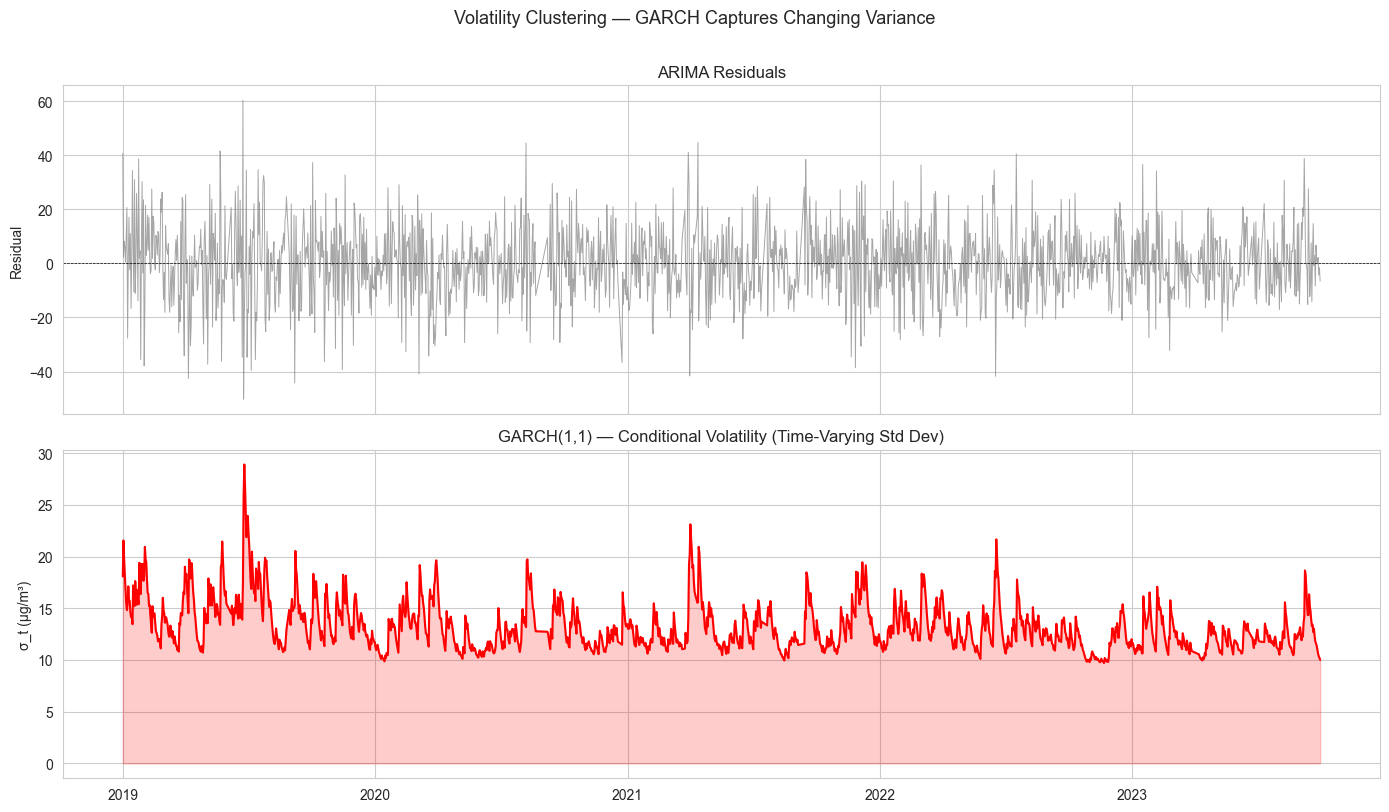

Volatility range: 9.70 → 28.91 µg/m³
Mean volatility: 13.27 µg/m³


In [8]:
# Plot conditional volatility
cond_vol = garch_fit.conditional_volatility / 100  # scale back

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(train.index, arima_resid.values, linewidth=0.7, color="gray", alpha=0.7)
axes[0].set_title("ARIMA Residuals")
axes[0].set_ylabel("Residual")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")

# Match lengths — use whichever is shorter
n = min(len(train.index), len(cond_vol))
axes[1].plot(train.index[-n:], cond_vol[-n:], linewidth=1.5, color="red")
axes[1].set_title(f"GARCH({best_p},{best_q}) — Conditional Volatility (Time-Varying Std Dev)")
axes[1].set_ylabel("σ_t (µg/m³)")
axes[1].fill_between(train.index[-n:], 0, cond_vol[-n:], alpha=0.2, color="red")

plt.suptitle("Volatility Clustering — GARCH Captures Changing Variance", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Volatility range: {cond_vol.min():.2f} → {cond_vol.max():.2f} µg/m³")
print(f"Mean volatility: {cond_vol.mean():.2f} µg/m³")

## 5. Walk-Forward: ARIMA-GARCH Combined (Rolling Only)

For each test day:
1. Fit ARIMA → get mean prediction
2. Fit GARCH on ARIMA residuals → get volatility prediction
3. Combine: prediction ± dynamic confidence intervals

In [10]:
# Walk-forward: ARIMA-GARCH combined (or load from cache)
WF_PATH = os.path.join(SAVED_DIR, "garch_walkforward.pkl")

if os.path.exists(WF_PATH):
    wf_data = pd.read_pickle(WF_PATH)
    wf_preds = wf_data["predictions"]
    wf_vols = wf_data["volatilities"]
    print(f"✓ Loaded cached walk-forward from {WF_PATH}")
else:
    history = list(train.values)
    wf_preds = []
    wf_vols = []

    for i in range(len(test)):
        # Step 1: ARIMA for mean
        arima_m = ARIMA(history, order=(1, 1, 2))
        arima_f = arima_m.fit()
        mean_pred = arima_f.forecast(steps=1)[0]

        # Step 2: GARCH for volatility on ARIMA residuals
        resid = np.array(arima_f.resid)
        resid = resid[~np.isnan(resid)] * 100  # remove NaN, scale up
        garch_m = arch_model(resid, vol="Garch", p=best_p, q=best_q, dist="t")
        garch_f = garch_m.fit(disp="off")
        vol_forecast = garch_f.forecast(horizon=1)
        vol_pred = np.sqrt(vol_forecast.variance.values[-1, 0]) / 100  # scale back

        wf_preds.append(mean_pred)
        wf_vols.append(vol_pred)
        history.append(test.values[i])

        if (i + 1) % 15 == 0:
            print(f"  Step {i+1}/{len(test)} done...")

    wf_preds = pd.Series(wf_preds, index=test.index)
    wf_vols = pd.Series(wf_vols, index=test.index)
    pickle.dump({"predictions": wf_preds, "volatilities": wf_vols}, open(WF_PATH, "wb"))
    print(f"\n✓ Saved walk-forward to {WF_PATH}")

# Metrics
wf_rmse = np.sqrt(mean_squared_error(test.values, wf_preds.values))
wf_mae = mean_absolute_error(test.values, wf_preds.values)
wf_mape = wf_mae / test.mean() * 100

print(f"\nARIMA-GARCH Walk-Forward Results:")
print(f"  RMSE: {wf_rmse:.2f} µg/m³")
print(f"  MAE:  {wf_mae:.2f} µg/m³")
print(f"  MAPE: {wf_mape:.1f}%")

  Step 15/90 done...
  Step 30/90 done...
  Step 45/90 done...
  Step 60/90 done...
  Step 75/90 done...
  Step 90/90 done...

✓ Saved walk-forward to saved/garch_walkforward.pkl

ARIMA-GARCH Walk-Forward Results:
  RMSE: 11.61 µg/m³
  MAE:  9.31 µg/m³
  MAPE: 20.7%


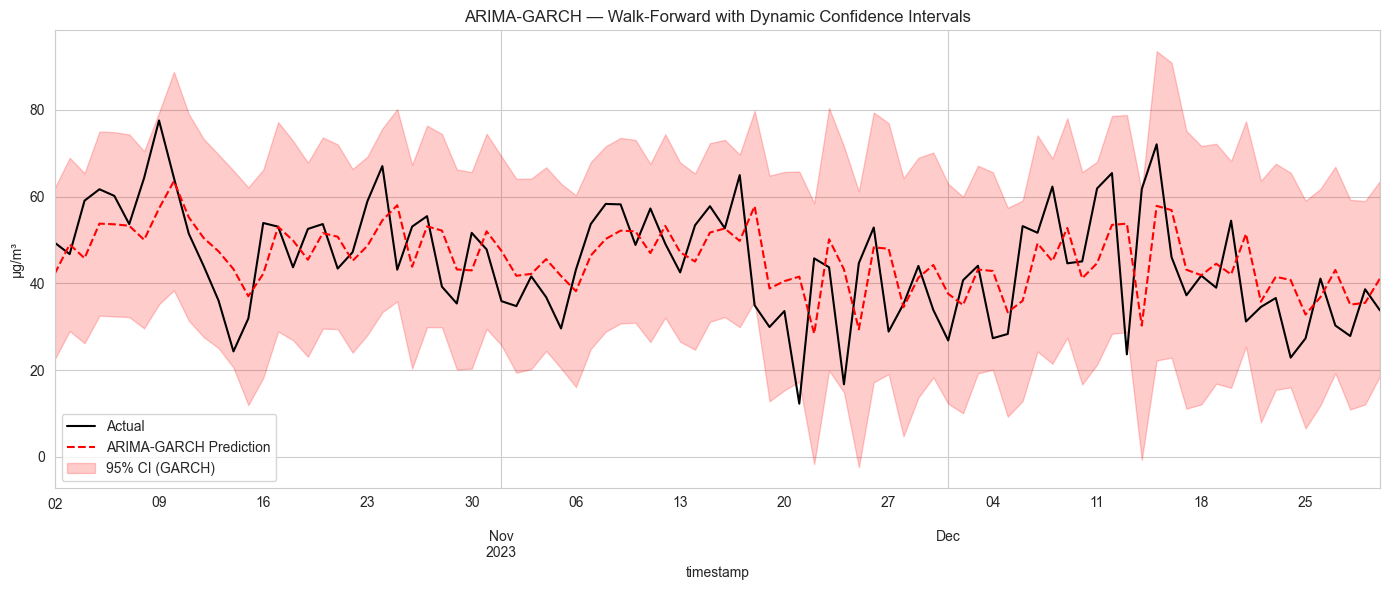

95% CI coverage: 95.6% of actuals fall within the GARCH confidence band


In [12]:
# Plot: prediction with DYNAMIC confidence intervals (GARCH-based)
fig, ax = plt.subplots(figsize=(14, 6))

test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
wf_preds.plot(ax=ax, label="ARIMA-GARCH Prediction", color="red", linestyle="--")

# Dynamic CI using GARCH volatility (±1.96σ for 95%)
upper = wf_preds + 1.96 * wf_vols
lower = wf_preds - 1.96 * wf_vols
ax.fill_between(test.index, lower, upper, alpha=0.2, color="red", label="95% CI (GARCH)")

ax.set_title("ARIMA-GARCH — Walk-Forward with Dynamic Confidence Intervals")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

# Coverage: what % of actuals fall within the CI?
within_ci = ((test >= lower) & (test <= upper)).mean() * 100
print(f"95% CI coverage: {within_ci:.1f}% of actuals fall within the GARCH confidence band")


## 6. ARIMA vs ARIMA-GARCH: Confidence Interval Comparison

The key value of GARCH is not better point predictions but **better uncertainty estimation**. ARIMA assumes constant variance (fixed CI width). GARCH gives **dynamic CI** that widens during volatile periods.

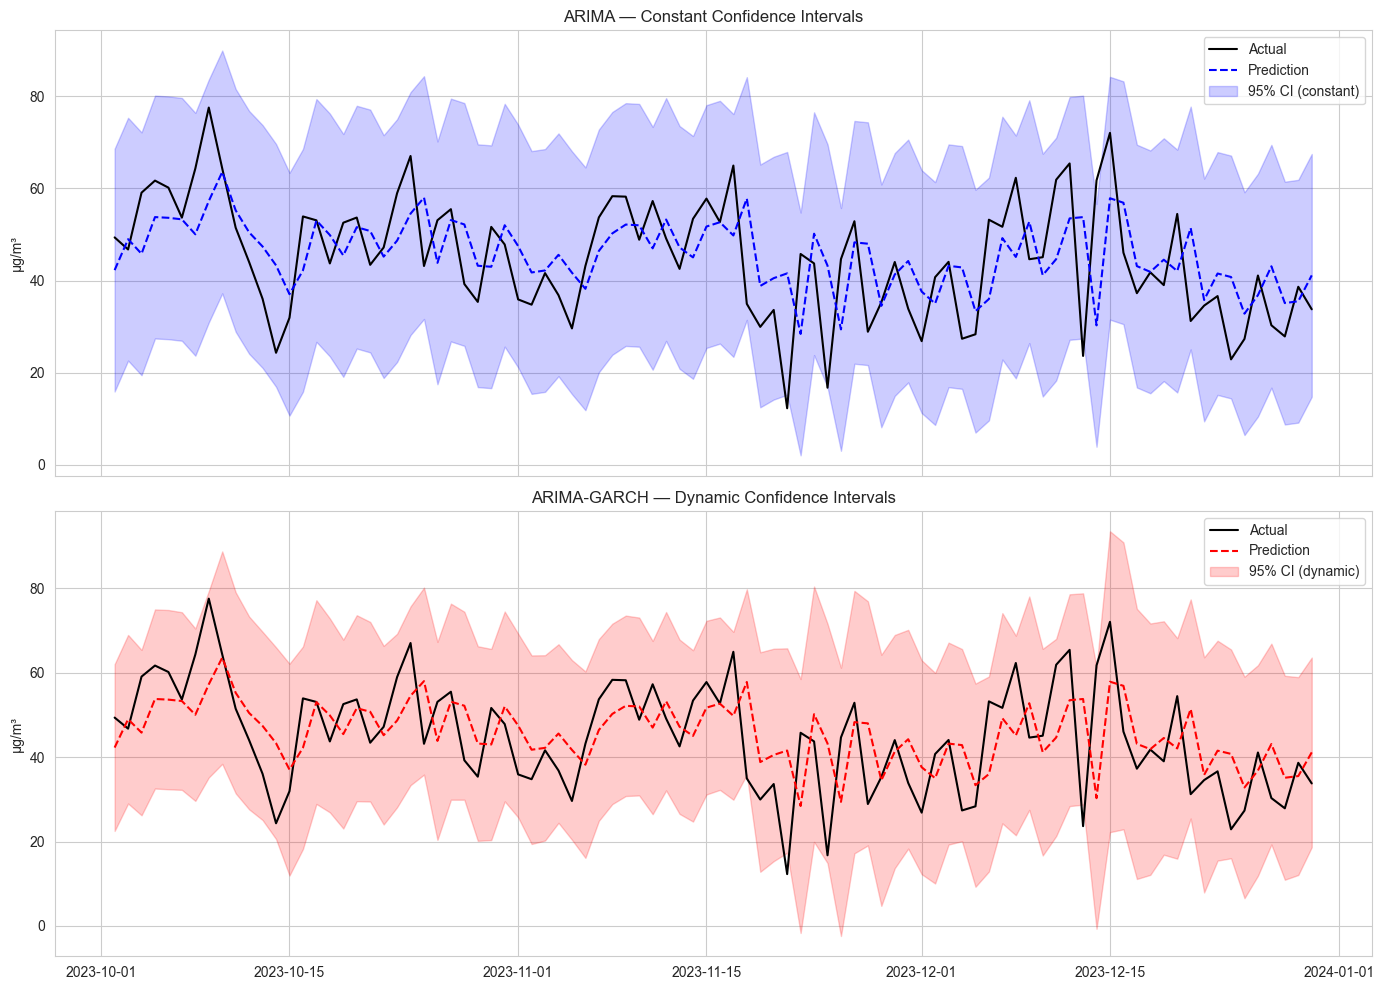

CI Coverage (should be ~95%):
  ARIMA (constant):     95.6%
  ARIMA-GARCH (dynamic): 95.6%

  CI width (avg):
  ARIMA: ±26.4 µg/m³ (fixed)
  GARCH: ±24.1 µg/m³ (avg, varies 19.6–35.7)


In [13]:
# Compare: constant CI (ARIMA) vs dynamic CI (GARCH)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ARIMA: constant CI
arima_std = arima_resid.std()
arima_upper = wf_preds + 1.96 * arima_std
arima_lower = wf_preds - 1.96 * arima_std

axes[0].plot(test.index, test.values, color="black", linewidth=1.5, label="Actual")
axes[0].plot(test.index, wf_preds.values, color="blue", linestyle="--", label="Prediction")
axes[0].fill_between(test.index, arima_lower, arima_upper, alpha=0.2, color="blue", label="95% CI (constant)")
axes[0].set_title("ARIMA — Constant Confidence Intervals")
axes[0].set_ylabel("µg/m³")
axes[0].legend()

# GARCH: dynamic CI
axes[1].plot(test.index, test.values, color="black", linewidth=1.5, label="Actual")
axes[1].plot(test.index, wf_preds.values, color="red", linestyle="--", label="Prediction")
axes[1].fill_between(test.index, lower, upper, alpha=0.2, color="red", label="95% CI (dynamic)")
axes[1].set_title("ARIMA-GARCH — Dynamic Confidence Intervals")
axes[1].set_ylabel("µg/m³")
axes[1].legend()

plt.tight_layout()
plt.show()

# Coverage comparison
arima_coverage = ((test >= arima_lower) & (test <= arima_upper)).mean() * 100
garch_coverage = within_ci
print(f"CI Coverage (should be ~95%):")
print(f"  ARIMA (constant):     {arima_coverage:.1f}%")
print(f"  ARIMA-GARCH (dynamic): {garch_coverage:.1f}%")
print(f"\n  CI width (avg):")
print(f"  ARIMA: ±{1.96*arima_std:.1f} µg/m³ (fixed)")
print(f"  GARCH: ±{1.96*wf_vols.mean():.1f} µg/m³ (avg, varies {1.96*wf_vols.min():.1f}–{1.96*wf_vols.max():.1f})")

## 7. All Models Comparison

In [14]:
# All models comparison (walk-forward only)
comparison = pd.DataFrame({
    "Model": [
        "ARIMA(1,1,2)",
        "SARIMA(1,1,2)(1,1,2,7)",
        "VAR(12)",
        f"ARIMA-GARCH({best_p},{best_q})",
    ],
    "RMSE": [11.61, 11.97, 31.14, wf_rmse],
    "MAE": [9.31, 9.50, 24.17, wf_mae],
    "MAPE (%)": [20.7, 21.1, 53.7, wf_mape],
})
display(comparison)

best_model = comparison.sort_values("RMSE").iloc[0]

print("\n" + "="*60)
print("KEY TAKEAWAYS (based on actual results)")
print("="*60)
print(f"• GARCH({best_p},{best_q}) models time-varying volatility of ARIMA residuals")
print(f"• α + β persistence: check summary above for volatility persistence")
print(f"• ARIMA-GARCH walk-forward RMSE: {wf_rmse:.2f} (same mean prediction as ARIMA)")
print(f"• GARCH's value is NOT better point forecasts — it's better UNCERTAINTY estimation")
print(f"• Dynamic CI coverage: {garch_coverage:.1f}% vs ARIMA constant CI: {arima_coverage:.1f}%")
print(f"• Best overall model (by RMSE): {best_model['Model']} ({best_model['RMSE']:.2f})")
print(f"• → Next: Anomaly Detection (Notebook 06) using model residuals")

,Model,RMSE,MAE,MAPE (%)
0,"ARIMA(1,1,2)",11.610000,9.310000,20.700000
1,"SARIMA(1,1,2)(1,1,2,7)",11.970000,9.500000,21.100000
2,VAR(12),31.140000,24.170000,53.700000
3,"ARIMA-GARCH(1,1)",11.606069,9.310698,20.681564



KEY TAKEAWAYS (based on actual results)
• GARCH(1,1) models time-varying volatility of ARIMA residuals
• α + β persistence: check summary above for volatility persistence
• ARIMA-GARCH walk-forward RMSE: 11.61 (same mean prediction as ARIMA)
• GARCH's value is NOT better point forecasts — it's better UNCERTAINTY estimation
• Dynamic CI coverage: 95.6% vs ARIMA constant CI: 95.6%
• Best overall model (by RMSE): ARIMA-GARCH(1,1) (11.61)
• → Next: Anomaly Detection (Notebook 06) using model residuals
